In [48]:
# import required libraries for predictive analysis

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
# import matplotlib  # Removed: No longer needed for Jupyter
# matplotlib.use('Agg')  # Fixed: Removed this line - it causes the warning in Jupyter
warnings.simplefilter(action='ignore', category=FutureWarning)
from scipy.stats import mannwhitneyu
from scipy.stats import chi2_contingency
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Add this magic command in a separate cell in Jupyter:
# %matplotlib inline

In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report,precision_score,recall_score,f1_score
import xgboost as xgb
from sklearn.metrics import roc_curve
warnings.filterwarnings('ignore', category=FutureWarning, module='pandas')
warnings.filterwarnings('ignore', category=FutureWarning, module='sklearn')

In [5]:
!pip install xgboost



  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)


In [ ]:
%matplotlib inline

# Read and Merge Diabetes Datasets

Combine diabetes monitoring data with demographic and sleep information into a unified dataset:

1. Read the cleaned diabetes monitoring dataset and demographic dataset using pandas
2. Convert the TimeStamp column into datetime format for temporal analysis
3. Merge both datasets using Patient_ID as the common key
4.Preserve all diabetes monitoring records using a left join
5.Combine glucose, insulin, activity, sleep, and demographic features into one dataset
6. Save the merged dataset as a new CSV file for machine learning and analysis
7.Preview the merged dataset using data.head() to validate the integration process

In [10]:
df = pd.read_csv(r"C:\Data Analyst_Resources\Python_Hackathon\HUPA-UC Diabetes Dataset\Practice_files\Cleaned_Diabetes_Data.csv")
demo = pd.read_csv(r"C:\Data Analyst_Resources\Python_Hackathon\HUPA-UC Diabetes Dataset\T1DM_patient_sleep_demographics_with_race.csv")

df["TimeStamp"] = pd.to_datetime(df["TimeStamp"])

data = df.merge(demo, on="Patient_ID", how="left")

data.to_csv(r"C:\Data Analyst_Resources\Python_Hackathon\HUPA-UC Diabetes Dataset\Practice_files\Merged_Diabetes_Data.csv", index=False)

data.head()

,Patient_ID,TimeStamp,Date,Time,Hour,Minutes,Blood_Glucose_mg_dl,Basal_Insulin_Rate_Unit_hr,Bolus_Insulin_Dose_Units,Carbohydrate_Intake_Grams,Step_count,Calories_burned,Heart_Rate_bpm,Age,Gender,Race,Average Sleep Duration (hrs),Sleep Quality (1-10),% with Sleep Disturbances
0,HUPA0001P,2018-06-13 18:40:00,2018-06-13,18:40:00,18,40,332.0,0.09,0.0,0.0,34.0,6.36,82.32,34,Male,Other,6.3,4.5,80
1,HUPA0001P,2018-06-13 18:45:00,2018-06-13,18:45:00,18,45,326.0,0.09,0.0,0.0,0.0,7.73,83.74,34,Male,Other,6.3,4.5,80
2,HUPA0001P,2018-06-13 18:50:00,2018-06-13,18:50:00,18,50,330.0,0.09,0.0,0.0,0.0,4.75,80.53,34,Male,Other,6.3,4.5,80
3,HUPA0001P,2018-06-13 18:55:00,2018-06-13,18:55:00,18,55,324.0,0.09,0.0,0.0,20.0,6.36,89.13,34,Male,Other,6.3,4.5,80
4,HUPA0001P,2018-06-13 19:00:00,2018-06-13,19:00:00,19,0,306.0,0.08,0.0,0.0,0.0,5.15,92.50,34,Male,Other,6.3,4.5,80


# Create Hypoglycemia Risk Target Variable
1. Used blood glucose readings to identify hypoglycemia events
2. Classified glucose values below 70 mg/dL as hypoglycemia risk
3. Converted the condition into binary format:
1 → Hypoglycemia Risk
0 → Normal Glucose Range
Applied .astype(int) to convert Boolean values into machine learning compatible numeric labels
4. Created a target variable for supervised classification models
5. Enabled prediction of low-glucose risk using machine learning algorithms

In [74]:
data["Hypoglycemia_Risk"] = (
    data["Blood_Glucose_mg_dl"] < 70
).astype(int)

# Feature Selection for Machine Learning Model
1. Selected physiological, insulin, activity, and time-based features relevant to glucose behavior
Included:
insulin dosage, 
carbohydrate intake, 
physical activity, 
heart rate, 
patient age
2. Used Hour and Minutes to capture time-dependent glucose patterns
3. Stored selected input features in X
4. Assigned Hypoglycemia_Risk as the target variable y for supervised learning classification models

In [75]:
features = [
    "Hour",
    "Minutes",
    "Basal_Insulin_Rate_Unit_hr",
    "Bolus_Insulin_Dose_Units",
    "Carbohydrate_Intake_Grams",
    "Step_count",
    "Calories_burned",
    "Heart_Rate_bpm",
    "Age"
]

X = data[features]

y = data["Hypoglycemia_Risk"]

In [76]:
print("Class Distribution:\n", y.value_counts(normalize=True))

Class Distribution:
 Hypoglycemia_Risk
0    0.934139
1    0.065861
Name: proportion, dtype: float64


### Train-Test Data Splitting

1. Split the dataset into training and testing sets using `train_test_split()`
2. Used:

   * 80% data for model training
   * 20% data for model testing
3. Applied `random_state=42` to ensure reproducible results
4. Used `stratify=y` to maintain the same class distribution in both training and testing datasets
5. Enabled unbiased evaluation of machine learning model performance on unseen data


In [77]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### Feature Scaling Using StandardScaler

1. Applied feature scaling using `StandardScaler()`
2. Standardized features to have:

   * mean = 0
   * standard deviation = 1
3. Used `fit_transform()` on training data to learn scaling parameters
4. Used `transform()` on testing data to apply the same scaling consistently
5. Improved model performance and convergence for machine learning algorithms sensitive to feature magnitudes, such as Logistic Regression and XGBoost


In [78]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Logistic Regression Model Training

1. Initialized the Logistic Regression classification model
2. Used `class_weight="balanced"` to address class imbalance in hypoglycemia data
3. Set `max_iter=1000` to allow sufficient iterations for model convergence
4. Trained the model using the scaled training dataset
5. Built a supervised learning model to predict hypoglycemia risk based on patient health and activity features


In [71]:
lr_model = LogisticRegression(max_iter=1000, class_weight="balanced")
lr_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


### Generate Predictions and Prediction Probabilities

1. Used the trained Logistic Regression model to predict hypoglycemia risk on testing data
2. Generated class predictions using `predict()`
3. Generated probability scores using `predict_proba()`
4. Extracted probability values for the positive hypoglycemia class (`1`)
5. Used prediction probabilities for:

   * ROC AUC evaluation
   * risk scoring
   * threshold analysis
   * model performance assessment


In [80]:
lr_pred = lr_model.predict(X_test)
lr_prob = lr_model.predict_proba(X_test)[:, 1]

### Model Performance Evaluation

1. Evaluated the Logistic Regression model using multiple classification metrics
2. Measured:

   * Accuracy → overall prediction correctness
   * Precision → proportion of correct positive predictions
   * Recall → ability to detect actual hypoglycemia events
   * F1 Score → balance between precision and recall
   * ROC AUC → overall model discrimination capability
3. Used prediction labels and probability scores to assess classification performance
4. Focused on recall and ROC AUC due to the medical importance of detecting hypoglycemia risk


In [81]:
print("Accuracy:", accuracy_score(y_test, lr_pred))

print("Precision:", precision_score(y_test, lr_pred))

print("Recall:", recall_score(y_test, lr_pred))

print("F1 Score:", f1_score(y_test, lr_pred))

print("ROC AUC:", roc_auc_score(y_test, lr_prob))



Accuracy: 0.5876630197643788
Precision: 0.08996328029375765
Recall: 0.5771779141104294
F1 Score: 0.1556636553161918
ROC AUC: 0.6048405676385569


### ROC Curve Visualization

1. Generated the ROC Curve using prediction probability scores from the Logistic Regression model
2. Calculated:

   * False Positive Rate (FPR)
   * True Positive Rate (TPR)
   * classification thresholds
3. Visualized the model’s ability to distinguish between hypoglycemia and normal glucose conditions
4. Used the ROC Curve to evaluate classification performance across multiple threshold values
5. Saved the ROC Curve plot as a high-resolution PNG image for reporting and presentation purposes
6. Displayed the visualization for model performance interpretation and comparison


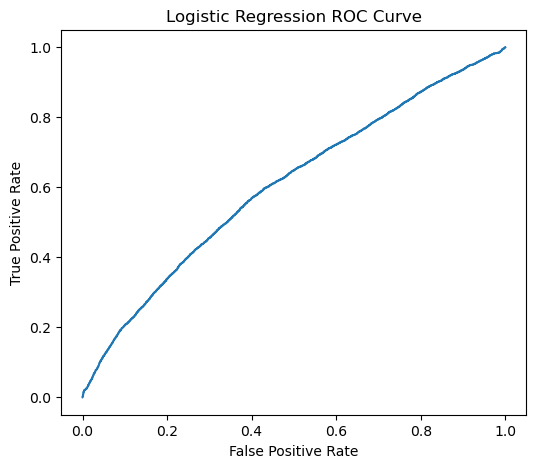

In [82]:
fpr, tpr, thresholds = roc_curve(y_test, lr_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Logistic Regression ROC Curve")

plt.savefig(r"C:\Data Analyst_Resources\Python_Hackathon\HUPA-UC Diabetes Dataset\Practice_files\roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()

### Improved Model Train-Test Data Splitting

1. Split the dataset into training and testing sets for improved model evaluation
2. Used:

   * 80% data for model training
   * 20% data for model testing
3. Applied `random_state=42` to ensure consistent and reproducible results
4. Used `stratify=y` to preserve the original class distribution of hypoglycemia cases in both datasets
5. Supported reliable evaluation of the improved machine learning model on unseen data
6. Helped address class imbalance during model training and testing phases


In [100]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [101]:
improved_lr_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

improved_lr_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [102]:
y_pred = improved_lr_model.predict(X_test)

y_prob = improved_lr_model.predict_proba(X_test)[:, 1]

In [103]:
print("Improved Logistic Regression Results")
print("-----------------------------------")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Improved Logistic Regression Results
-----------------------------------
Accuracy: 0.587905428335946
Precision: 0.09004630515479699
Recall: 0.5774233128834356
F1 Score: 0.15579686155068528
ROC AUC: 0.6048125525097929

Confusion Matrix:
[[34026 23778]
 [ 1722  2353]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.59      0.73     57804
           1       0.09      0.58      0.16      4075

    accuracy                           0.59     61879
   macro avg       0.52      0.58      0.44     61879
weighted avg       0.90      0.59      0.69     61879



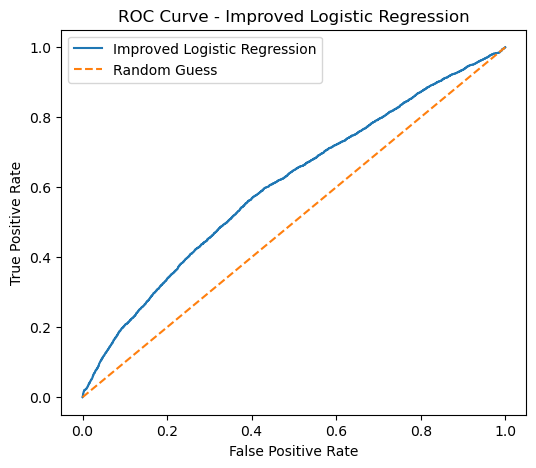

In [104]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label="Improved Logistic Regression")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Improved Logistic Regression")
plt.legend()
plt.show()

In [ ]:
# MODEL 2 — Random Forest

### Random Forest Model Training

1. Initialized the Random Forest classification model
2. Used `n_estimators=100` to build 100 decision trees for ensemble learning
3. Applied `random_state=42` to ensure reproducible model results
4. Trained the model using the prepared training dataset
5. Leveraged ensemble learning to capture complex and nonlinear glucose behavior patterns
6. Built a robust classification model for hypoglycemia risk prediction


In [30]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### Generate Random Forest Predictions and Probability Scores

1. Used the trained Random Forest model to predict hypoglycemia risk on testing data
2. Generated class predictions using `predict()`
3. Generated probability scores using `predict_proba()`
4. Extracted probability values for the positive hypoglycemia risk class (`1`)
5. Used probability scores for:

   * ROC Curve generation
   * ROC AUC evaluation
   * risk probability analysis
   * model performance comparison


In [31]:
rf_pred = rf_model.predict(X_test)

rf_prob = rf_model.predict_proba(X_test)[:,1]

### Random Forest Model Performance Evaluation

1. Evaluated the Random Forest model using multiple classification performance metrics
2. Measured:

   * Accuracy → overall prediction correctness
   * Precision → correctness of predicted hypoglycemia cases
   * Recall → ability to identify actual hypoglycemia events
   * F1 Score → balance between precision and recall
   * ROC AUC → overall classification and discrimination capability
3. Used prediction labels and probability scores for comprehensive model evaluation
4. Compared Random Forest performance against other machine learning models for hypoglycemia risk prediction


In [32]:
print("Accuracy:", accuracy_score(y_test, rf_pred))

print("Precision:", precision_score(y_test, rf_pred))

print("Recall:", recall_score(y_test, rf_pred))

print("F1 Score:", f1_score(y_test, rf_pred))

print("ROC AUC:", roc_auc_score(y_test, rf_prob))

Accuracy: 0.9347759336770148
Precision: 0.516209476309227
Recall: 0.1523926380368098
F1 Score: 0.23531640773020082
ROC AUC: 0.7712066755734313


### Random Forest ROC Curve Visualization

1. Generated the ROC Curve using Random Forest prediction probability scores
2. Calculated:

   * False Positive Rate (FPR)
   * True Positive Rate (TPR)
   * classification thresholds
3. Visualized the model’s capability to distinguish between hypoglycemia and normal glucose conditions
4. Evaluated classification performance across different decision thresholds
5. Used the ROC Curve to assess and compare Random Forest model effectiveness against other machine learning models


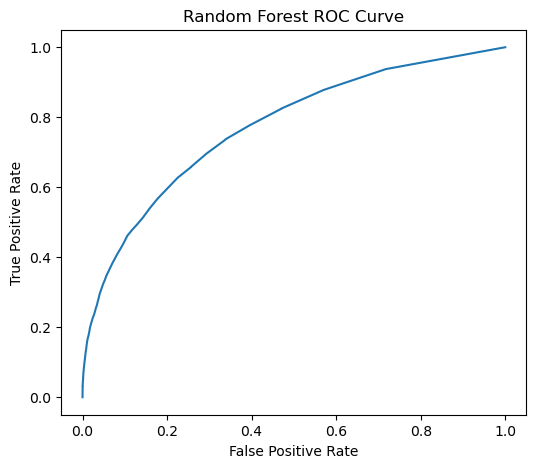

In [34]:
fpr, tpr, thresholds = roc_curve(y_test, rf_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest ROC Curve")

plt.show()

### XGBoost Model Training

1. Initialized the XGBoost classification model for hypoglycemia risk prediction
2. Used `n_estimators=100` to build multiple boosting trees for ensemble learning
3. Applied `learning_rate=0.1` to control the contribution of each tree during training
4. Set `max_depth=5` to limit tree complexity and reduce overfitting
5. Used `random_state=42` to ensure reproducible model results
6. Trained the model using the prepared training dataset
7. Leveraged gradient boosting to capture complex nonlinear relationships in glucose and patient health data
st

In [37]:
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

xgb_model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


### Generate XGBoost Predictions and Probability Scores

1. Used the trained XGBoost model to predict hypoglycemia risk on testing data
2. Generated class predictions using `predict()`
3. Generated probability scores using `predict_proba()`
4. Extracted probability values for the positive hypoglycemia risk class (`1`)
5. Used prediction probabilities for:

   * ROC Curve generation
   * ROC AUC evaluation
   * probability-based risk assessment
   * model performance comparison across classifiers


In [38]:
xgb_pred = xgb_model.predict(X_test)

xgb_prob = xgb_model.predict_proba(X_test)[:,1]

### XGBoost Model Performance Evaluation

1. Evaluated the XGBoost model using multiple classification performance metrics
2. Measured:

   * Accuracy → overall prediction correctness
   * Precision → correctness of predicted hypoglycemia cases
   * Recall → ability to detect actual hypoglycemia events
   * F1 Score → balance between precision and recall
   * ROC AUC → overall classification and discrimination capability
3. Used both prediction labels and probability scores for comprehensive model evaluation
4. Assessed the effectiveness of the gradient boosting model for hypoglycemia risk prediction and comparison with other machine learning models


In [39]:
print("Accuracy:", accuracy_score(y_test, xgb_pred))

print("Precision:", precision_score(y_test, xgb_pred))

print("Recall:", recall_score(y_test, xgb_pred))

print("F1 Score:", f1_score(y_test, xgb_pred))

print("ROC AUC:", roc_auc_score(y_test, xgb_prob))

Accuracy: 0.9346628096769501
Precision: 0.6212121212121212
Recall: 0.020122699386503066
F1 Score: 0.03898264796767292
ROC AUC: 0.7504806405228924


### XGBoost ROC Curve Visualization

1. Generated the ROC Curve using XGBoost prediction probability scores
2. Calculated:

   * False Positive Rate (FPR)
   * True Positive Rate (TPR)
   * classification thresholds
3. Visualized the model’s capability to distinguish between hypoglycemia and normal glucose conditions
4. Evaluated classification performance across different threshold values
5. Used the ROC Curve to assess the predictive strength of the XGBoost model
6. Compared XGBoost performance with Logistic Regression and Random Forest models for hypoglycemia risk prediction


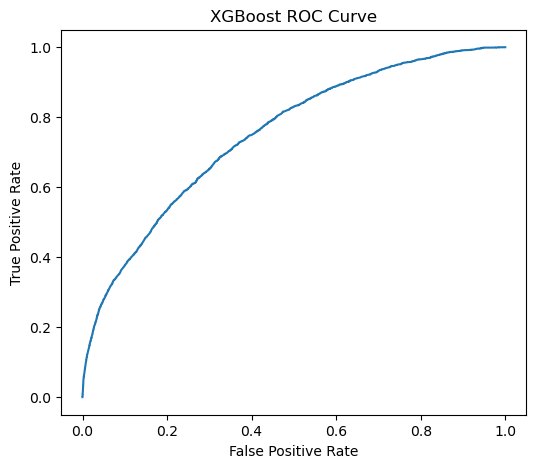

In [47]:
fpr, tpr, thresholds = roc_curve(y_test, xgb_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("XGBoost ROC Curve")

plt.show()

### Hypoglycemia Model Comparison Summary

1. Created a comparison table using `pandas DataFrame`
2. Compared the performance of:

   * Improved Logistic Regression
   * Random Forest
   * XGBoost
3. Evaluated each model using key classification metrics:

   * Accuracy
   * Precision
   * Recall
   * F1 Score
   * ROC AUC
4. Converted metric values into percentage format for easier interpretation and presentation
5. Used `zero_division=0` to safely handle undefined precision or recall scenarios
6. Rounded all metric values to 2 decimal places for better readability
7. Displayed the final comparison table to analyze and compare model performance for hypoglycemia risk prediction


In [108]:

hypo_results = pd.DataFrame({
    "Model": [
        "Improved Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy (%)": [
        accuracy_score(y_test, improved_lr_pred) * 100,
        accuracy_score(y_test, rf_pred) * 100,
        accuracy_score(y_test, xgb_pred) * 100
    ],

    "Precision (%)": [
        precision_score(y_test, improved_lr_pred, zero_division=0) * 100,
        precision_score(y_test, rf_pred, zero_division=0) * 100,
        precision_score(y_test, xgb_pred, zero_division=0) * 100
    ],

    "Recall (%)": [
        recall_score(y_test, improved_lr_pred, zero_division=0) * 100,
        recall_score(y_test, rf_pred, zero_division=0) * 100,
        recall_score(y_test, xgb_pred, zero_division=0) * 100
    ],

    "F1 Score (%)": [
        f1_score(y_test, improved_lr_pred, zero_division=0) * 100,
        f1_score(y_test, rf_pred, zero_division=0) * 100,
        f1_score(y_test, xgb_pred, zero_division=0) * 100
    ],

    "ROC AUC (%)": [
        roc_auc_score(y_test, improved_lr_prob) * 100,
        roc_auc_score(y_test, rf_prob) * 100,
        roc_auc_score(y_test, xgb_prob) * 100
    ]
})

hypo_results = hypo_results.round(2)

display(hypo_results)


,Model,Accuracy (%),Precision (%),Recall (%),F1 Score (%),ROC AUC (%)
0,Improved Logistic Regression,93.41,0.00,0.00,0.00,60.21
1,Random Forest,93.48,51.79,15.26,23.58,77.21
2,XGBoost,93.66,69.25,6.58,12.01,78.36


### Hypoglycemia Model Interpretation and Best Model Selection

1. Added strengths for each machine learning model based on performance characteristics
2. Defined practical healthcare usage scenarios for:

   * Improved Logistic Regression
   * Random Forest
   * XGBoost
3. Used ROC AUC score to identify the best-performing hypoglycemia prediction model
4. Selected the model with the highest ROC AUC as the final recommended model
5. Displayed the best model details for performance interpretation and comparison
6. Supported final model selection for hypoglycemia risk prediction and healthcare monitoring applications


In [90]:

# Hypoglycemia Model Results Summary

hypo_results["Strengths"] = [
    "High Recall for Early Detection",
    "Handles Nonlinear Glucose Patterns",
    "Best Overall Predictive Capability"
]

hypo_results["Usage"] = [
    "Early Hypoglycemia Warning System",
    "General Hypoglycemia Risk Detection",
    "Advanced AI-Based Hypoglycemia Prediction"
]

# Find Best Model based on ROC AUC
best_hypo_model = hypo_results.loc[
    hypo_results["ROC AUC (%)"].idxmax()
]

print("Best Hypoglycemia Model:")
print(best_hypo_model)



Best Hypoglycemia Model:
Model                                  Random Forest
Accuracy (%)                                   93.48
Precision (%)                                  51.62
Recall (%)                                     15.24
F1 Score (%)                                   23.53
ROC AUC (%)                                    77.12
Strengths         Handles Nonlinear Glucose Patterns
Usage            General Hypoglycemia Risk Detection
Name: 1, dtype: object
